In [1]:
%%time

##################################
#Imports

from datetime import datetime
import s3fs
import xarray as xr
import pyinterp
from widetrax import DataPreprocessing as dp
from widetrax import Spectra as sp
import numpy as np
import json
from watermark import watermark
import time
import platform
from shapely.geometry import shape, box
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
#from widetrax import Spectra as sp
import plot_ration_psd as ppR



CPU times: user 3.5 s, sys: 717 ms, total: 4.21 s
Wall time: 1.65 s


In [2]:
reg="AG"


if reg=="GS":
    roi = {
        "lon_min": -60,
        "lon_max": -50,
        "lat_min": 30,
        "lat_max": 40
    }
    pos_reg=[-85, -30, 15, 55]
elif reg=="AG":
    roi = {
        "lon_min": 20,
        "lon_max": 40,
        "lat_min": -40,
        "lat_max": -20
    }
    pos_reg=[0, 60, -55, -25]

with open("mostly_ocean_boxes_filtered.geojson") as f:
    data = json.load(f)

roi_poly = box(roi["lon_min"], roi["lat_min"],
               roi["lon_max"], roi["lat_max"])

selected = []

for feature in data["features"]:
    poly = shape(feature["geometry"])
    if poly.intersects(roi_poly):
        selected.append(poly)

/Users/contrema/Documents/Postdoc/SWOTv2/plot_ration_psd.py:68: RuntimeWarning: divide by zero encountered in divide
  mask = (1 / freqs) >= (2 * max_horizontal_gridsize[i])
/Users/contrema/Documents/Postdoc/SWOTv2/plot_ration_psd.py:114: RuntimeWarning: divide by zero encountered in divide
  ax2 = ax.secondary_xaxis("bottom", functions=(lambda x: 1 / x, lambda x: 1 / x))
/Users/contrema/Documents/Postdoc/SWOTv2/plot_ration_psd.py:114: RuntimeWarning: divide by zero encountered in divide
  ax2 = ax.secondary_xaxis("bottom", functions=(lambda x: 1 / x, lambda x: 1 / x))
/Users/contrema/Documents/Postdoc/SWOTv2/plot_ration_psd.py:68: RuntimeWarning: divide by zero encountered in divide
  mask = (1 / freqs) >= (2 * max_horizontal_gridsize[i])
/Users/contrema/Documents/Postdoc/SWOTv2/plot_ration_psd.py:114: RuntimeWarning: divide by zero encountered in divide
  ax2 = ax.secondary_xaxis("bottom", functions=(lambda x: 1 / x, lambda x: 1 / x))
/Users/contrema/Documents/Postdoc/SWOTv2/plot_rat

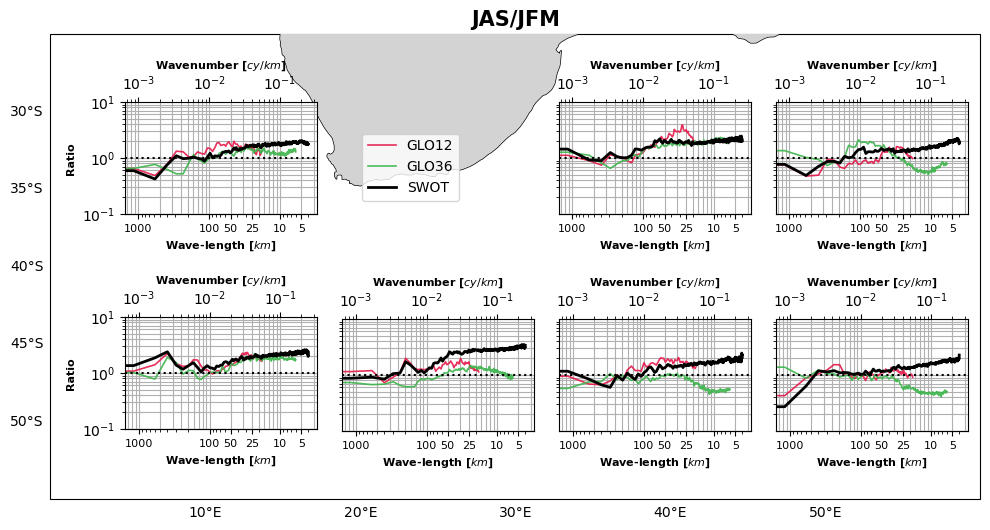

In [3]:


#import importlib
#importlib.reload(ppR)
colors = [
    "#E6194B",  # red
    "#3CB44B",  # green
    "k",
    #"#FFE119",  # yellow
    #"#4363D8",  # blue
    #"#F58231",  # orange
    #"#911EB4",  # purple
]

models=["GLO12","GLO36","SWOT"]

max_horizontal_gridsize = [9,3,0] #,2.224,2.224,25,7,0]

fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent(pos_reg, crs=ccrs.PlateCarree())
gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=2,
    color='gray',
    alpha=0.5,
    linestyle='--'
)

# Optional: clean up label placement
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 10}
gl.ylabel_style = {'size': 10}
gl.xlines = False
gl.ylines = False
ax.set_title("JAS/JFM",fontsize=15, fontweight="bold", color="black")
ax.add_feature(cfeature.LAND,zorder=10, facecolor="lightgray")
ax.add_feature(cfeature.COASTLINE)
#for poly in selected:
#    ax.add_geometries([poly], ccrs.PlateCarree(),
#                      edgecolor="black", facecolor="none")

box=0
for i, poly in enumerate(selected):

    if (reg=="AG"): 
        # Box center
        lon_min, lat_min, lon_max, lat_max = poly.bounds
        lon_c = 0.7 * (lon_min + lon_max)
        lat_c = 0.7 * (lat_min + lat_max)

        # Convert lon/lat → figure coordinates
        x_fig, y_fig = ax.transData.transform(
         ccrs.PlateCarree().transform_point(lon_c-10, lat_c+16, ccrs.PlateCarree())
        )
        x_fig, y_fig = fig.transFigure.inverted().transform((x_fig, y_fig))
        w, h = 0.16, 0.14
        if box==0:
            inset_ax = fig.add_axes([x_fig - w/2, y_fig - h/6, w, h])
        else:
            inset_ax = fig.add_axes([x_fig - w/2, y_fig - h/2, w, h])
    elif (reg=="GS"): 
        lon_min, lat_min, lon_max, lat_max = poly.bounds
        lon_c = 0.6 * (lon_min + lon_max)
        lat_c = 0.6 * (lat_min + lat_max)

        # Convert lon/lat → figure coordinates
        x_fig, y_fig = ax.transData.transform(
            ccrs.PlateCarree().transform_point(lon_c+15, lat_c-5, ccrs.PlateCarree())
        )
        x_fig, y_fig = fig.transFigure.inverted().transform((x_fig, y_fig))
        w, h = 0.14, 0.12
        inset_ax = fig.add_axes([x_fig - w/2, y_fig - h/2, w, h])
        

    season="JFM"
    spectrumJFM=[]
    freqJFM=[]
    # Plot spectrum JFM
    for imod in ["GLORYS12","GLORYS36","SWOT"]:
        filename = reg + "_box_" + str(box) + "_" + season + "_" + imod + ".json"
        with open(filename, "r") as f:
            data = json.load(f)
        spectrumJFM.append(data["Spectra"])
        freqJFM.append(data["Frequency"])

    season="JAS"
    spectrumJAS=[]
    freqJAS=[]
    # Plot spectrum JFM
    for imod in ["GLORYS12","GLORYS36","SWOT"]:
        filename = reg + "_box_" + str(box) + "_" + season + "_" + imod + ".json"
        with open(filename, "r") as f:
            data = json.load(f)
        spectrumJAS.append(data["Spectra"])
        freqJAS.append(data["Frequency"])

    freq=freqJAS
    psds1 = np.array(spectrumJAS / np.where(spectrumJFM == 0, np.nan, spectrumJFM))
        
    if box==0:
        ppR.plot_psd(inset_ax, np.array(freq[0]).T, psds = psds1, unit = "m2",psd_labels=models,legend=True,
                     loc_leg='upper left',bba_leg=(1.2,2.7), xlabel_upper=True,xlabel_lower=True, ylabel=True,
                     colors=colors,max_horizontal_gridsize=max_horizontal_gridsize,
                     savefig=True,filename=(reg +"_ratio_" + season + ".png"),plot_transparent=False)
    else:
        if (box!=4): # & (box!=6):
            ppR.plot_psd(inset_ax, np.array(freq[0]).T, psds = psds1, unit = "m2",psd_labels=models,legend=False,
                    xlabel_upper=True,xlabel_lower=True, ylabel=False, colors=colors,max_horizontal_gridsize=max_horizontal_gridsize,
                    savefig=True,filename=(reg +"_ratio_" + season + ".png"),plot_transparent=False)
            #inset_ax.set_xticks([])
            inset_ax.tick_params(axis='y', labelleft=False, length=0)
        else:
            ppR.plot_psd(inset_ax, np.array(freq[0]).T,  psds = psds1, unit = "m2",psd_labels=models,legend=False,
                    xlabel_upper=True,xlabel_lower=True, ylabel=True,colors=colors,max_horizontal_gridsize=max_horizontal_gridsize,
                    savefig=True, filename=(reg +"_ratio_" + season + ".png"),plot_transparent=False)
    box=box+1

In [13]:
np.shape(spectrum)


(2, 297)

In [135]:
freqs=np.array(freq_GLORYS[0]).T
spectra=np.array(spectra_GLORYS).T
non_zero_freqs = freqs[freqs != 0]
np.shape(non_zero_freqs)
k_2 = non_zero_freqs ** -2 * (spectra[0][0]/ (non_zero_freqs[0] ** -2))